In [25]:
import os
import sys
import time
import random

from __future__ import annotations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk", font_scale=0.9)
plt.rcParams.update({
    "figure.facecolor": "#f6f7fb",
    "axes.facecolor": "#f6f7fb",
    "axes.edgecolor": "#d0d4e4",
    "axes.labelcolor": "#1c1f26",
    "text.color": "#1c1f26",
    "xtick.color": "#1c1f26",
    "ytick.color": "#1c1f26",
    "grid.color": "#e3e6ef",
    "grid.linewidth": 0.8,
    "font.family": "sans-serif",
    "axes.titleweight": "600",
    "axes.labelweight": "500",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RESULTS_DIR = "../app/results/"

In [26]:
from __future__ import annotations

import ast
from pathlib import Path

import pandas as pd


def _parse_scalar(raw: str):
    raw = raw.strip()
    lowered = raw.lower()
    if lowered in {"true", "false"}:
        return lowered == "true"
    try:
        return int(raw)
    except ValueError:
        pass
    try:
        return float(raw)
    except ValueError:
        pass
    return raw


def parse_ga_result_file(path: Path) -> dict:
    """Parse files written by ga_core.results.save_results_csv (semicolon-delimited)."""
    rows: dict[str, object] = {"path": str(path)}

    text = path.read_text(encoding="utf-8")
    lines = [ln.rstrip("\n") for ln in text.splitlines()]

    i = 0
    if lines and lines[0].lower().startswith("parameter;"):
        i = 1

    while i < len(lines):
        line = lines[i]
        i += 1
        if not line.strip():
            continue
        if line.lower().startswith("epoch;"):
            break
        key, sep, val = line.partition(";")
        if sep == "":
            continue
        key, val = key.strip(), val.strip()

        if key == "best_variables":
            # list-like string; safe eval only for literals
            try:
                rows[key] = ast.literal_eval(val)
            except (SyntaxError, ValueError):
                rows[key] = val
        elif key in {"best_fitness", "elapsed_s"}:
            rows[key] = float(val)
        else:
            rows[key] = _parse_scalar(val)

    return rows


def load_results_dir(results_dir: str | Path) -> pd.DataFrame:
    results_dir = Path(results_dir)
    paths = sorted(results_dir.glob("run_*_*.csv"))
    records = [parse_ga_result_file(p) for p in paths]

    df = pd.DataFrame.from_records(records)

    wanted = ["path", "variant", "pop_size", "selection", "k", "early_stop", "patience", "best_fitness", "elapsed_s"]
    existing = [c for c in wanted if c in df.columns]
    return df[existing]

In [27]:
df = load_results_dir(RESULTS_DIR)
df.head()

,path,variant,pop_size,selection,k,early_stop,patience,best_fitness,elapsed_s
0,../app/results/run_binary_20260412_183936.csv,binary,100,best,3,True,20,0.001860,0.156
1,../app/results/run_binary_20260412_222157.csv,binary,100,best,3,False,20,0.138919,0.543
2,../app/results/run_binary_20260412_222209.csv,binary,200,best,3,False,20,0.090400,1.087
3,../app/results/run_binary_20260412_222213.csv,binary,300,best,3,False,20,0.003228,1.357
4,../app/results/run_binary_20260412_222218.csv,binary,400,best,3,False,20,0.112976,1.971


In [28]:
VARIANT_PALETTE = {"binary": "#0072B2", "real": "#D55E00"}
EARLY_PALETTE = {True: "#009E73", False: "#CC79A7"}


def _nice_number_axis(ax, which="y"):
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))


def plot_variant_comparison(df: pd.DataFrame) -> plt.Figure:
    d = df.copy()
    d["variant"] = pd.Categorical(d["variant"], categories=["binary", "real"], ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6), dpi=120, constrained_layout=True)

    sns.stripplot(
        data=d, x="variant", y="best_fitness", hue="variant",
        order=["binary", "real"], palette=VARIANT_PALETTE,
        dodge=False, legend=False, alpha=0.55, jitter=0.22, linewidth=0, s=7, ax=axes[0],
    )
    sns.boxplot(
        data=d, x="variant", y="best_fitness", order=["binary", "real"],
        width=0.35, showcaps=False, boxprops={"facecolor": (0, 0, 0, 0)},
        whiskerprops={"linewidth": 1.2}, medianprops={"color": "#222", "linewidth": 2},
        flierprops={"marker": ""}, ax=axes[0],
    )
    axes[0].set_title("Best fitness by encoding")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("best_fitness")

    sns.stripplot(
        data=d, x="variant", y="elapsed_s", hue="variant",
        order=["binary", "real"], palette=VARIANT_PALETTE,
        dodge=False, legend=False, alpha=0.55, jitter=0.22, linewidth=0, s=7, ax=axes[1],
    )
    sns.boxplot(
        data=d, x="variant", y="elapsed_s", order=["binary", "real"],
        width=0.35, showcaps=False, boxprops={"facecolor": (0, 0, 0, 0)},
        whiskerprops={"linewidth": 1.2}, medianprops={"color": "#222", "linewidth": 2},
        flierprops={"marker": ""}, ax=axes[1],
    )
    axes[1].set_title("Wall time by encoding")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("elapsed_s")

    for ax in axes:
        ax.grid(True, axis="y", linestyle="--", alpha=0.55)
        _nice_number_axis(ax)

    fig.suptitle("Binary vs real runs", fontsize=15, weight="650", y=1.02)
    return fig


def plot_early_stop_effect(df: pd.DataFrame) -> plt.Figure:
    d = df.copy()
    d["variant"] = pd.Categorical(d["variant"], categories=["binary", "real"], ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), dpi=120, constrained_layout=True)

    sns.pointplot(
        data=d, x="early_stop", y="best_fitness", hue="variant",
        palette=VARIANT_PALETTE, dodge=0.35, errorbar=("ci", 95),
        markers=["o", "s"], linestyles=["-", "-"], capsize=0.12, ax=axes[0],
    )
    axes[0].set_title("Best fitness vs early stopping")
    axes[0].set_xlabel("early_stop")
    axes[0].set_ylabel("best_fitness")
    sns.move_legend(axes[0], "upper left", frameon=True, title=None)

    sns.pointplot(
        data=d, x="early_stop", y="elapsed_s", hue="variant",
        palette=VARIANT_PALETTE, dodge=0.35, errorbar=("ci", 95),
        markers=["o", "s"], linestyles=["-", "-"], capsize=0.12, ax=axes[1],
    )
    axes[1].set_title("Wall time vs early stopping")
    axes[1].set_xlabel("early_stop")
    axes[1].set_ylabel("elapsed_s")
    sns.move_legend(axes[1], "upper left", frameon=True, title=None)

    for ax in axes:
        ax.grid(True, axis="y", linestyle="--", alpha=0.55)
        _nice_number_axis(ax)

    fig.suptitle("Early stopping × encoding", fontsize=15, weight="650", y=1.02)
    return fig

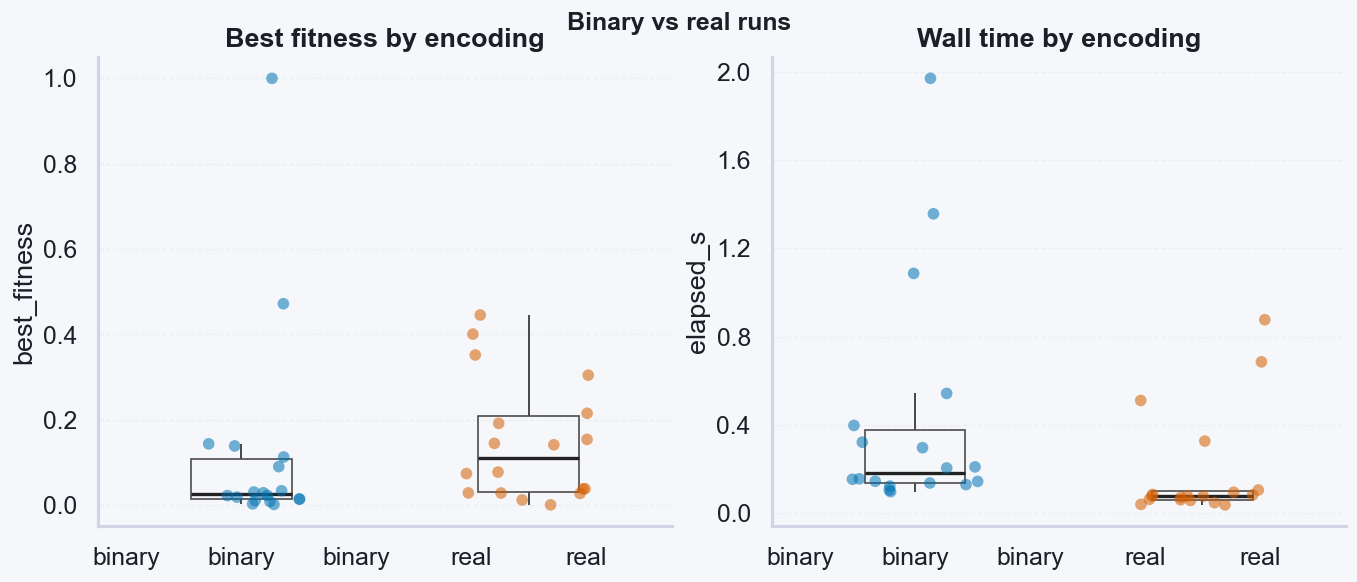

In [30]:
fig = plot_variant_comparison(df); fig.savefig("output/binary_real_comparison.png"); plt.show()